# Retail supplier warehouse: the numbers

Every number in the README, on the portfolio card and in `powerbi/06-checks.md` comes from this notebook.
It reads the finished star schema (`marts`) with plain SQL, so the same queries can check the Power BI report.

**Run it after** `docker compose up -d` and one run of the `retail_warehouse` DAG. It reads the password from `.env`.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import psycopg

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
CHARTS = ROOT / "docs" / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)

env = dict(line.split("=", 1) for line in (ROOT / ".env").read_text().splitlines() if "=" in line and not line.startswith("#"))
conn = psycopg.connect(host="localhost", port=5441, dbname="warehouse", user="warehouse", password=env["WAREHOUSE_PASSWORD"])

def q(sql):
    """Run a query and return a DataFrame."""
    with conn.cursor() as cur:
        cur.execute(sql)
        return pd.DataFrame(cur.fetchall(), columns=[c.name for c in cur.description])

ACCENT, GREY = "#2563EB", "#94A3B8"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
numbers = {}  # every headline number, collected for the summary at the end

## 1. What was loaded

The raw tables hold the files exactly as exported; the fact table is the cleaned star schema. The counts must agree.

In [2]:
loaded = q("""
    select distinct on (table_name) table_name, rows_loaded, loaded_at
    from raw.load_log
    order by table_name, loaded_at desc""")
star = q("""
    select count(distinct order_id) as orders,
           count(*)                 as order_items,
           count(distinct seller_id) as sellers_with_sales,
           count(distinct product_id) as products_sold,
           (select count(distinct department) from marts.dim_product) as departments,
           min(order_date) as first_order, max(order_date) as last_order
    from marts.fact_order_items""")
numbers["raw orders loaded"] = int(q("select count(*) as n from raw.orders").n[0])
numbers["orders in the fact table"] = int(star.orders[0])
numbers["order items"] = int(star.order_items[0])
numbers["sellers with sales"] = int(star.sellers_with_sales[0])
numbers["departments"] = int(star.departments[0])
display(loaded)
star

,table_name,rows_loaded,loaded_at
0,category_translation,71,2026-10-04 22:11:03.967946+00:00
1,customers,99441,2026-10-04 22:11:03.967946+00:00
2,order_items,112650,2026-10-04 22:11:03.967946+00:00
3,orders,99441,2026-10-04 22:11:03.967946+00:00
4,products,32951,2026-10-04 22:11:03.967946+00:00
5,reviews,99224,2026-10-04 22:11:03.967946+00:00
6,sellers,3095,2026-10-04 22:11:03.967946+00:00


,orders,order_items,sellers_with_sales,products_sold,departments,first_order,last_order
0,98666,112650,3095,32951,74,2016-09-04,2018-09-03


The raw file has 99,441 orders; the fact table has a few hundred fewer because some orders (mostly canceled or unavailable) have no items. Those orders stay in `raw.orders` and `staging.stg_orders`; the fact is built from items.

## 2. Data tests passing

`dbt build` writes `dbt/target/run_results.json` on every run. This counts its data tests by status.

In [3]:
run = json.loads((ROOT / "dbt" / "target" / "run_results.json").read_text())
tests = [r for r in run["results"] if r["unique_id"].startswith("test.")]
status = pd.Series([r["status"] for r in tests]).value_counts()
numbers["data tests passing"] = int(status.get("pass", 0))
numbers["data tests in total"] = len(tests)
print("dbt run finished at", run["metadata"]["generated_at"])
status

dbt run finished at 2026-10-04T22:11:27.910907Z


pass    31
Name: count, dtype: int64

## 3. How often deliveries are late

**Late** = the order was delivered (`order_status = 'delivered'` with a delivery date) and arrived after the promised date, comparing days.
Orders are counted once; items are counted per row, because one order can hold items from different sellers.

In [4]:
late = q("""
    select count(distinct order_id) filter (where is_delivered) as delivered_orders,
           count(distinct order_id) filter (where is_late)      as late_orders,
           count(*) filter (where is_delivered)                 as delivered_items,
           count(*) filter (where is_late)                      as late_items
    from marts.fact_order_items""").iloc[0]
numbers["late order rate"] = late.late_orders / late.delivered_orders
numbers["late item rate"] = late.late_items / late.delivered_items
numbers["late items"] = int(late.late_items)
late

delivered_orders     96470
late_orders           6534
delivered_items     110189
late_items            7264
Name: 0, dtype: int64

## 4. Which sellers cause the late deliveries

Sellers are the store's suppliers. Rank them by late items; the **top 100** are the 100 with the most late items (ties broken by `seller_id`, the same rule as the Power BI measure).
To be fair, compare their share of late items with their share of all delivered items: big sellers are expected to have more late items simply because they ship more.

In [5]:
sellers = q("""
    select seller_id,
           count(*) filter (where is_delivered) as delivered_items,
           count(*) filter (where is_late)      as late_items,
           row_number() over (order by count(*) filter (where is_late) desc, seller_id) as late_rank
    from marts.fact_order_items
    group by seller_id""")
top = sellers[sellers.late_rank <= 100]
numbers["top 100 sellers: share of late items"] = top.late_items.sum() / sellers.late_items.sum()
numbers["top 100 sellers: share of delivered items"] = top.delivered_items.sum() / sellers.delivered_items.sum()
numbers["top 100 sellers: late item rate"] = top.late_items.sum() / top.delivered_items.sum()
numbers["other sellers: late item rate"] = (sellers.late_items.sum() - top.late_items.sum()) / (sellers.delivered_items.sum() - top.delivered_items.sum())
numbers["sellers with at least one late item"] = int((sellers.late_items > 0).sum())
{k: v for k, v in numbers.items() if "top 100" in k or "other" in k or "at least" in k}

{'top 100 sellers: share of late items': np.float64(0.5038546255506607),
 'top 100 sellers: share of delivered items': np.float64(0.41603063826697767),
 'top 100 sellers: late item rate': np.float64(0.07983944854063958),
 'other sellers: late item rate': np.float64(0.056008827140348424),
 'sellers with at least one late item': 1274}

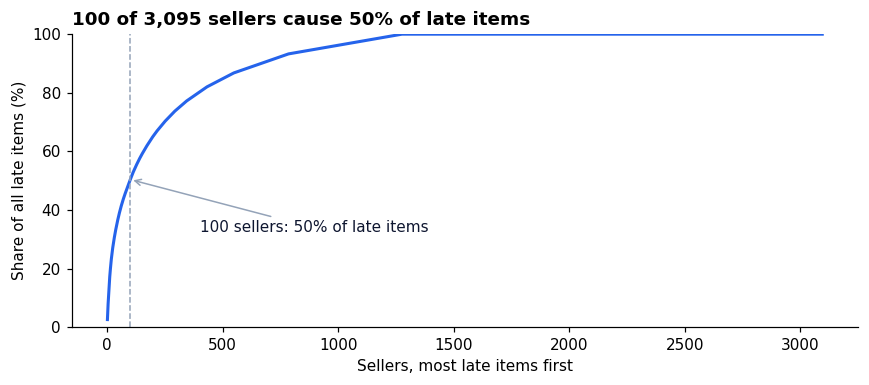

In [6]:
ranked = sellers.sort_values("late_items", ascending=False).reset_index(drop=True)
cum = ranked.late_items.cumsum() / ranked.late_items.sum()
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(range(1, len(cum) + 1), cum * 100, color=ACCENT, lw=2)
ax.axvline(100, color=GREY, ls="--", lw=1)
share = numbers["top 100 sellers: share of late items"] * 100
ax.annotate(f"100 sellers: {share:.0f}% of late items", xy=(100, share), xytext=(400, share - 18),
            arrowprops=dict(arrowstyle="->", color=GREY), color="#0E1630")
ax.set_xlabel("Sellers, most late items first")
ax.set_ylabel("Share of all late items (%)")
ax.set_title(f"100 of {len(sellers):,} sellers cause {share:.0f}% of late items", loc="left", fontweight="bold")
ax.set_ylim(0, 100)
fig.tight_layout()
fig.savefig(CHARTS / "late-items-by-seller.png", dpi=150)
plt.show()

## 5. Late deliveries cost reviews

Average review score (1 to 5) per order, each reviewed order counted once, late against on time.

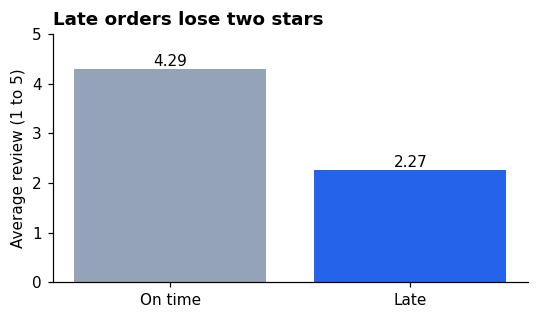

,delivery,average_review,reviewed_orders
0,On time,4.29,89443
1,Late,2.27,6381


In [7]:
reviews = q("""
    select case when is_late then 'Late' else 'On time' end as delivery,
           avg(review_score)::numeric(4, 2) as average_review,
           count(*) as reviewed_orders
    from (select distinct order_id, is_late, review_score
          from marts.fact_order_items
          where is_delivered and review_score is not null) o
    group by 1 order by 1 desc""")
numbers["average review, on time"] = float(reviews.set_index("delivery").average_review["On time"])
numbers["average review, late"] = float(reviews.set_index("delivery").average_review["Late"])
fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(reviews.delivery, reviews.average_review.astype(float), color=[GREY, ACCENT])
ax.bar_label(bars, fmt="%.2f")
ax.set_ylim(0, 5)
ax.set_ylabel("Average review (1 to 5)")
ax.set_title("Late orders lose two stars", loc="left", fontweight="bold")
fig.tight_layout()
fig.savefig(CHARTS / "review-late-vs-on-time.png", dpi=150)
plt.show()
reviews

## 6. Late rate by department

The ten departments with the most delivered items.

In [8]:
departments = q("""
    select p.department,
           count(*) filter (where f.is_delivered) as delivered_items,
           count(*) filter (where f.is_late)      as late_items,
           round(100.0 * count(*) filter (where f.is_late) / nullif(count(*) filter (where f.is_delivered), 0), 1) as late_rate_pct
    from marts.fact_order_items f
    join marts.dim_product p using (product_id)
    group by p.department
    order by delivered_items desc
    limit 10""")
departments

,department,delivered_items,late_items,late_rate_pct
0,bed bath table,10953,770,7.0
1,health beauty,9465,716,7.6
2,sports leisure,8430,532,6.3
3,furniture decor,8160,574,7.0
4,computers accessories,7643,496,6.5
5,housewares,6795,340,5.0
6,watches gifts,5857,422,7.2
7,telephony,4430,308,7.0
8,garden tools,4268,280,6.6
9,auto,4139,291,7.0


## 7. Sales (for the Power BI checks)

Sales are item prices without freight, in the store's currency (BRL), over all orders whatever their status: the same as the Power BI `Sales` measure.

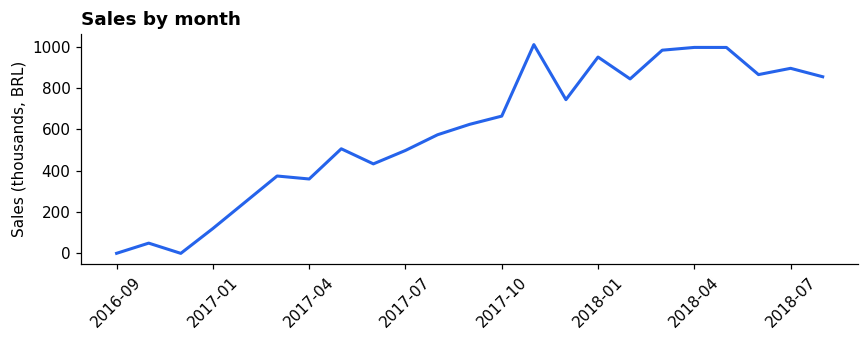

sales                           13591643.70
freight                          2251909.54
orders                                98666
average_order_value    137.7540763788944520
Name: 0, dtype: object

In [9]:
sales = q("""
    select sum(price) as sales, sum(freight) as freight,
           count(distinct order_id) as orders,
           sum(price) / count(distinct order_id) as average_order_value
    from marts.fact_order_items""").iloc[0]
numbers["sales"] = float(sales.sales)
numbers["freight"] = float(sales.freight)
numbers["freight % of sales"] = float(sales.freight / sales.sales)
numbers["average order value"] = float(sales.average_order_value)
delivery_days = q("""
    select avg(delivery_days)::numeric(5, 1) as average_delivery_days
    from (select distinct order_id, delivery_days from marts.fact_order_items where is_delivered) o""")
numbers["average delivery days"] = float(delivery_days.average_delivery_days[0])
numbers["average review, all orders"] = float(q("""
    select avg(review_score)::numeric(4, 2) as r
    from (select distinct order_id, review_score from marts.fact_order_items where review_score is not null) o""").r[0])

monthly = q("""
    select d.year_month, sum(f.price) as sales
    from marts.fact_order_items f join marts.dim_date d on d.date = f.order_date
    group by d.year_month order by d.year_month""")
monthly = monthly[monthly.year_month < "2018-09"]  # the data ends on 3 September 2018: leave the partial month out
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(monthly.year_month, monthly.sales.astype(float) / 1000, color=ACCENT, lw=2)
ax.set_xticks(monthly.year_month[::3])
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("Sales (thousands, BRL)")
ax.set_title("Sales by month", loc="left", fontweight="bold")
fig.tight_layout()
fig.savefig(CHARTS / "sales-by-month.png", dpi=150)
plt.show()
sales

## 8. Summary

The numbers used in the README, on the portfolio card and in `powerbi/06-checks.md`.

In [10]:
def show(name, value):
    if "rate" in name or "share" in name or "%" in name:
        return f"{value:.1%}"
    return f"{value:,.2f}" if isinstance(value, float) else f"{value:,}"

pd.DataFrame({"value": {name: show(name, value) for name, value in numbers.items()}})

,value
raw orders loaded,"99,441"
orders in the fact table,"98,666"
order items,"112,650"
sellers with sales,"3,095"
departments,74
data tests passing,31
data tests in total,31
late order rate,6.8%
late item rate,6.6%
late items,"7,264"
